###***Introduction***

This notebook presents a YOLOv8 object detection project focused on identifying motorcycle safety compliance features, including helmets, reflectors, and overload conditions. The workflow covers data loading, model training, validation, and evaluation using key performance metrics and visualization tools such as the confusion matrix. The goal is to accurately detect and classify multiple safety-related objects to support road safety monitoring and enforcement.


##1.Setting up dependencies
This code segment installs the required dependencies — **Ultralytics** for YOLOv8 model training and **Roboflow** for dataset access — and then imports the core libraries needed for the project. These include modules for model handling (`YOLO`), dataset loading (`Roboflow`), file and path operations (`os`, `glob`), data visualization (`matplotlib.pyplot`), and inline image display within the notebook (`IPython.display`). It prepares the environment for all subsequent steps in model training and evaluation.




In [ ]:
!pip install ultralytics roboflow --quiet

# Import libraries
from ultralytics import YOLO
from roboflow import Roboflow
import os
import glob
import matplotlib.pyplot as plt
from IPython.display import Image, display

###2.Downloading dataset and checking path

This code segment connects the notebook to the **Roboflow platform** using the user’s private API key and accesses the specified project — *“boda-boda-safety-jc2tt”* — within the workspace *“boda-boda-safety-dataset.”* It then downloads **version 1** of the dataset in **YOLOv8 format**, ensuring compatibility with the Ultralytics framework. Finally, `dataset.location` displays the path where the dataset has been stored locally, confirming a successful download and setup for training.


In [ ]:
rf = Roboflow(api_key="JY5I5Ez6s6Ev8T4Q3FYe")
project = rf.workspace("boda-boda-safety-dataset").project("boda-boda-safety-jc2tt")
dataset = project.version(1).download("yolov8")
# Check dataset path
dataset.location

loading Roboflow workspace...
loading Roboflow project...


'/content/Boda-boda-safety-1'

###3.Verifying dataset structure

This code lists the **contents of the downloaded dataset directory** using the Linux `ls` command. It helps verify that the dataset was correctly downloaded and structured. Typically, the output should display subfolders like `train`, `valid`, and `test`, along with a `data.yaml` file, which defines the dataset configuration for YOLO training.


In [ ]:
!ls {dataset.location}


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


###4.Model training

This code trains a YOLOv8 small model (`yolov8s.pt`) on the boda boda safety dataset to detect items such as helmets and safety vests. Using the dataset configuration file (`data.yaml`), the model is fine-tuned for 60 epochs with images resized to 640×640 pixels and a batch size of 16. Early stopping is disabled to ensure full training. All results — including model weights, logs, and metrics — are saved under the **“boda_boda_yolov8/yolov8_v1_1_model”** directory. In essence, this step customizes a pretrained YOLOv8 model for the specific detection needs of the dataset.


In [ ]:
model = YOLO("yolov8s.pt")

# Train model
model.train(
    data=os.path.join(dataset.location, "data.yaml"),  # dataset config file
    epochs=60,
    imgsz=640,
    batch=16,
    patience=0,
    project="boda_boda_yolov8",  # output folder
    name="yolov8_v1_1_model"
)

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Boda-boda-safety-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_v1_1_model4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=0, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd1c322b170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

###5.Evaluating performance on validation set

This code evaluates the trained YOLOv8 model on the validation dataset to measure its performance. The `model.val()` function runs inference on the validation images and computes key metrics such as **precision**, **recall**, **mean Average Precision (mAP50 and mAP50-95)**, and **F1-score**. These metrics help assess how accurately the model detects and classifies objects. The `print(metrics)` command then displays these results in the notebook for easy review.


In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2094.9±737.5 MB/s, size: 70.2 KB)
val: Scanning /content/Boda-boda-safety-1/valid/labels.cache... 174 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 331.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.0s
                   all        174        560      0.848      0.806      0.849      0.557
                helmet         97        102      0.867      0.912      0.933      0.628
             no_helmet         81         85       0.73      0.729      0.807      0.391
           no_overload        168        180       0.95      0.967       0.98      0.845
          no_reflector         52         53      0.751      0.736      0.773      0.329
              overload          5  

###Metrics discussion

This validation output summarizes the YOLOv8 model’s detection performance across all classes in the dataset. The results show strong overall metrics, with a **precision of 0.848**, **recall of 0.806**, and a **mean Average Precision (mAP50) of 0.849**, indicating that the model accurately identifies most objects with few false positives or missed detections. Class-wise results reveal particularly high accuracy for *no_overload* and *helmet*, while classes with fewer samples, like *overload* and *no_reflector*, perform slightly lower. The overall **mAP50-95 of 0.557** suggests moderate localization precision across varying IoU thresholds.


###6.Visualizing sample predictions

This code selects a few sample images from the validation set and runs the trained YOLOv8 model to make predictions on them. Each image is passed through the model with a confidence threshold of 0.25, meaning only detections with at least 25% confidence are displayed. The predictions are saved automatically, and the annotated images—with bounding boxes and class labels—are displayed directly in the notebook for visual inspection. This helps assess how well the model performs on unseen validation images.



image 1/1 /content/Boda-boda-safety-1/valid/images/IMG_8847_jpeg.rf.5b1c289266fee995e266f5e84fea2344.jpg: 640x640 1 no_helmet, 1 overload, 15.9ms
Speed: 1.8ms preprocess, 15.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


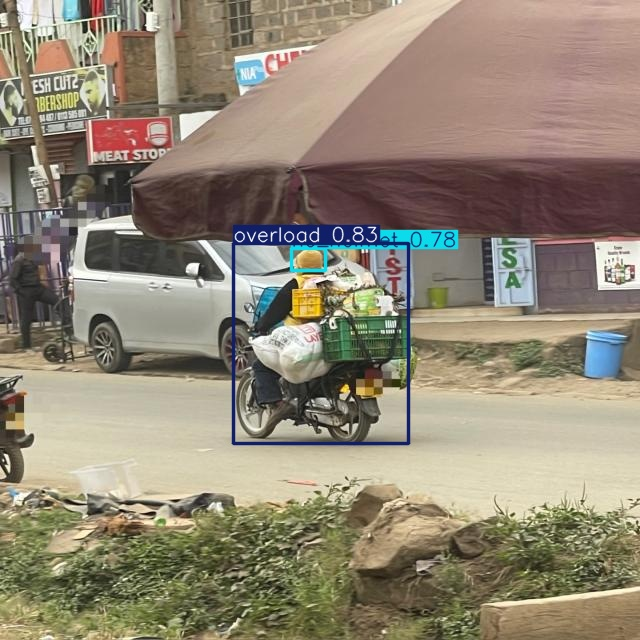

Predictions for IMG_8847_jpeg.rf.5b1c289266fee995e266f5e84fea2344.jpg

image 1/1 /content/Boda-boda-safety-1/valid/images/IMG_9144_jpeg.rf.d0c3c18c0216925440a505d402075c1c.jpg: 640x640 1 no_helmet, 1 no_overload, 1 reflector, 15.9ms
Speed: 2.3ms preprocess, 15.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


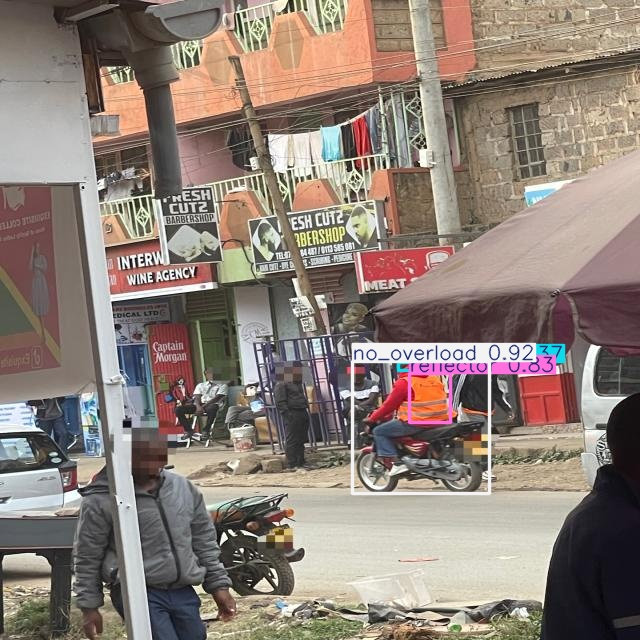

Predictions for IMG_9144_jpeg.rf.d0c3c18c0216925440a505d402075c1c.jpg

image 1/1 /content/Boda-boda-safety-1/valid/images/IMG_9522_jpeg.rf.314ad06cc7e2cba355b3ee3314373499.jpg: 640x640 1 helmet, 1 no_helmet, 2 no_overloads, 2 reflectors, 15.9ms
Speed: 2.2ms preprocess, 15.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


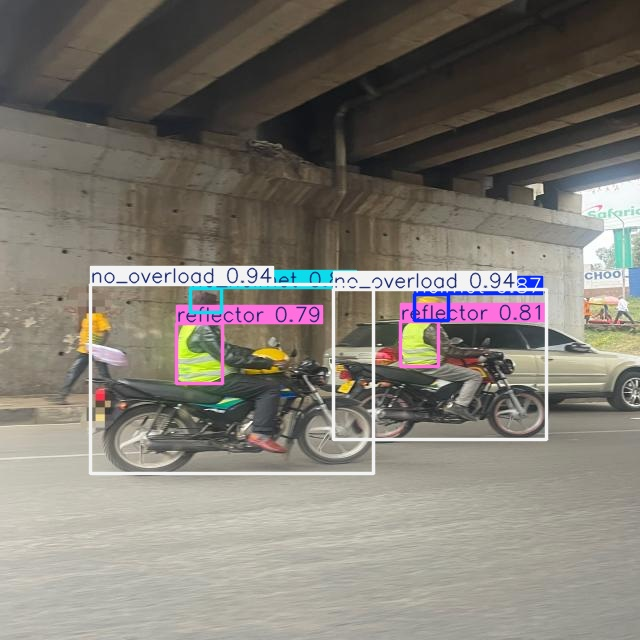

Predictions for IMG_9522_jpeg.rf.314ad06cc7e2cba355b3ee3314373499.jpg

image 1/1 /content/Boda-boda-safety-1/valid/images/IMG_9190_jpeg.rf.cb690b0538381572018e40aa8801ee48.jpg: 640x640 1 no_helmet, 1 no_overload, 1 reflector, 15.9ms
Speed: 1.9ms preprocess, 15.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


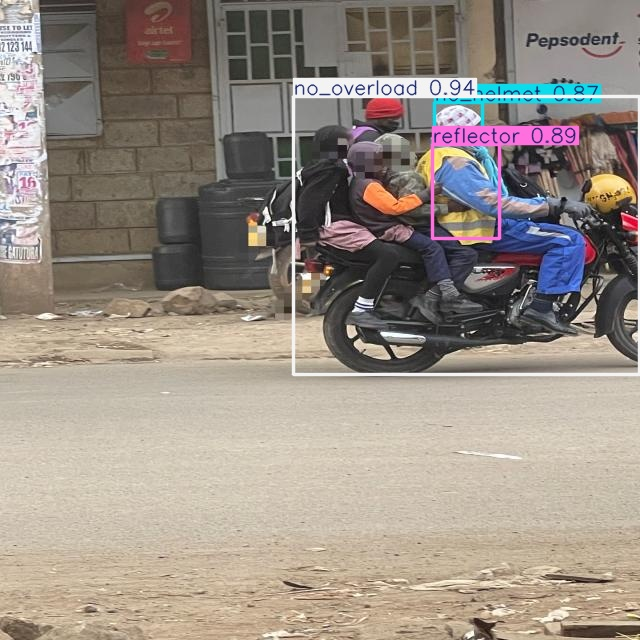

Predictions for IMG_9190_jpeg.rf.cb690b0538381572018e40aa8801ee48.jpg

image 1/1 /content/Boda-boda-safety-1/valid/images/IMG_7082_jpeg.rf.2fbff858bcb2bcae7f72296d2febbf85.jpg: 640x640 1 no_helmet, 1 no_overload, 1 no_reflector, 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


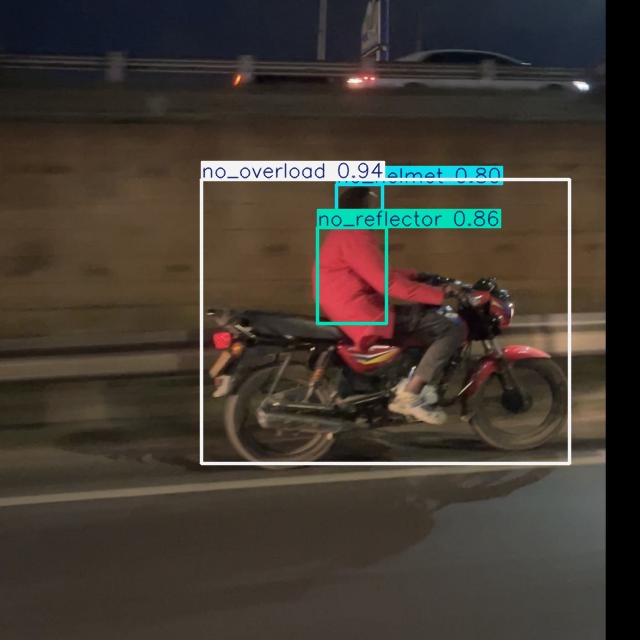

Predictions for IMG_7082_jpeg.rf.2fbff858bcb2bcae7f72296d2febbf85.jpg


In [ ]:
validation_images = glob.glob(os.path.join(dataset.location, "valid", "images", "*.jpg"))[:5]
for img_path in validation_images:
    results = model.predict(source=img_path, save=True, conf=0.25)
    display(Image(filename=results[0].save_dir + "/" + os.path.basename(img_path)))
    print(f"Predictions for {os.path.basename(img_path)}")


###7.Visualize training results

This code displays the training results image generated by YOLOv8, which summarizes key performance metrics such as training and validation loss, precision, recall, and mean Average Precision (mAP). By visualizing these curves, you can quickly assess the model’s learning progress, detect potential overfitting or underfitting, and evaluate overall training performance.


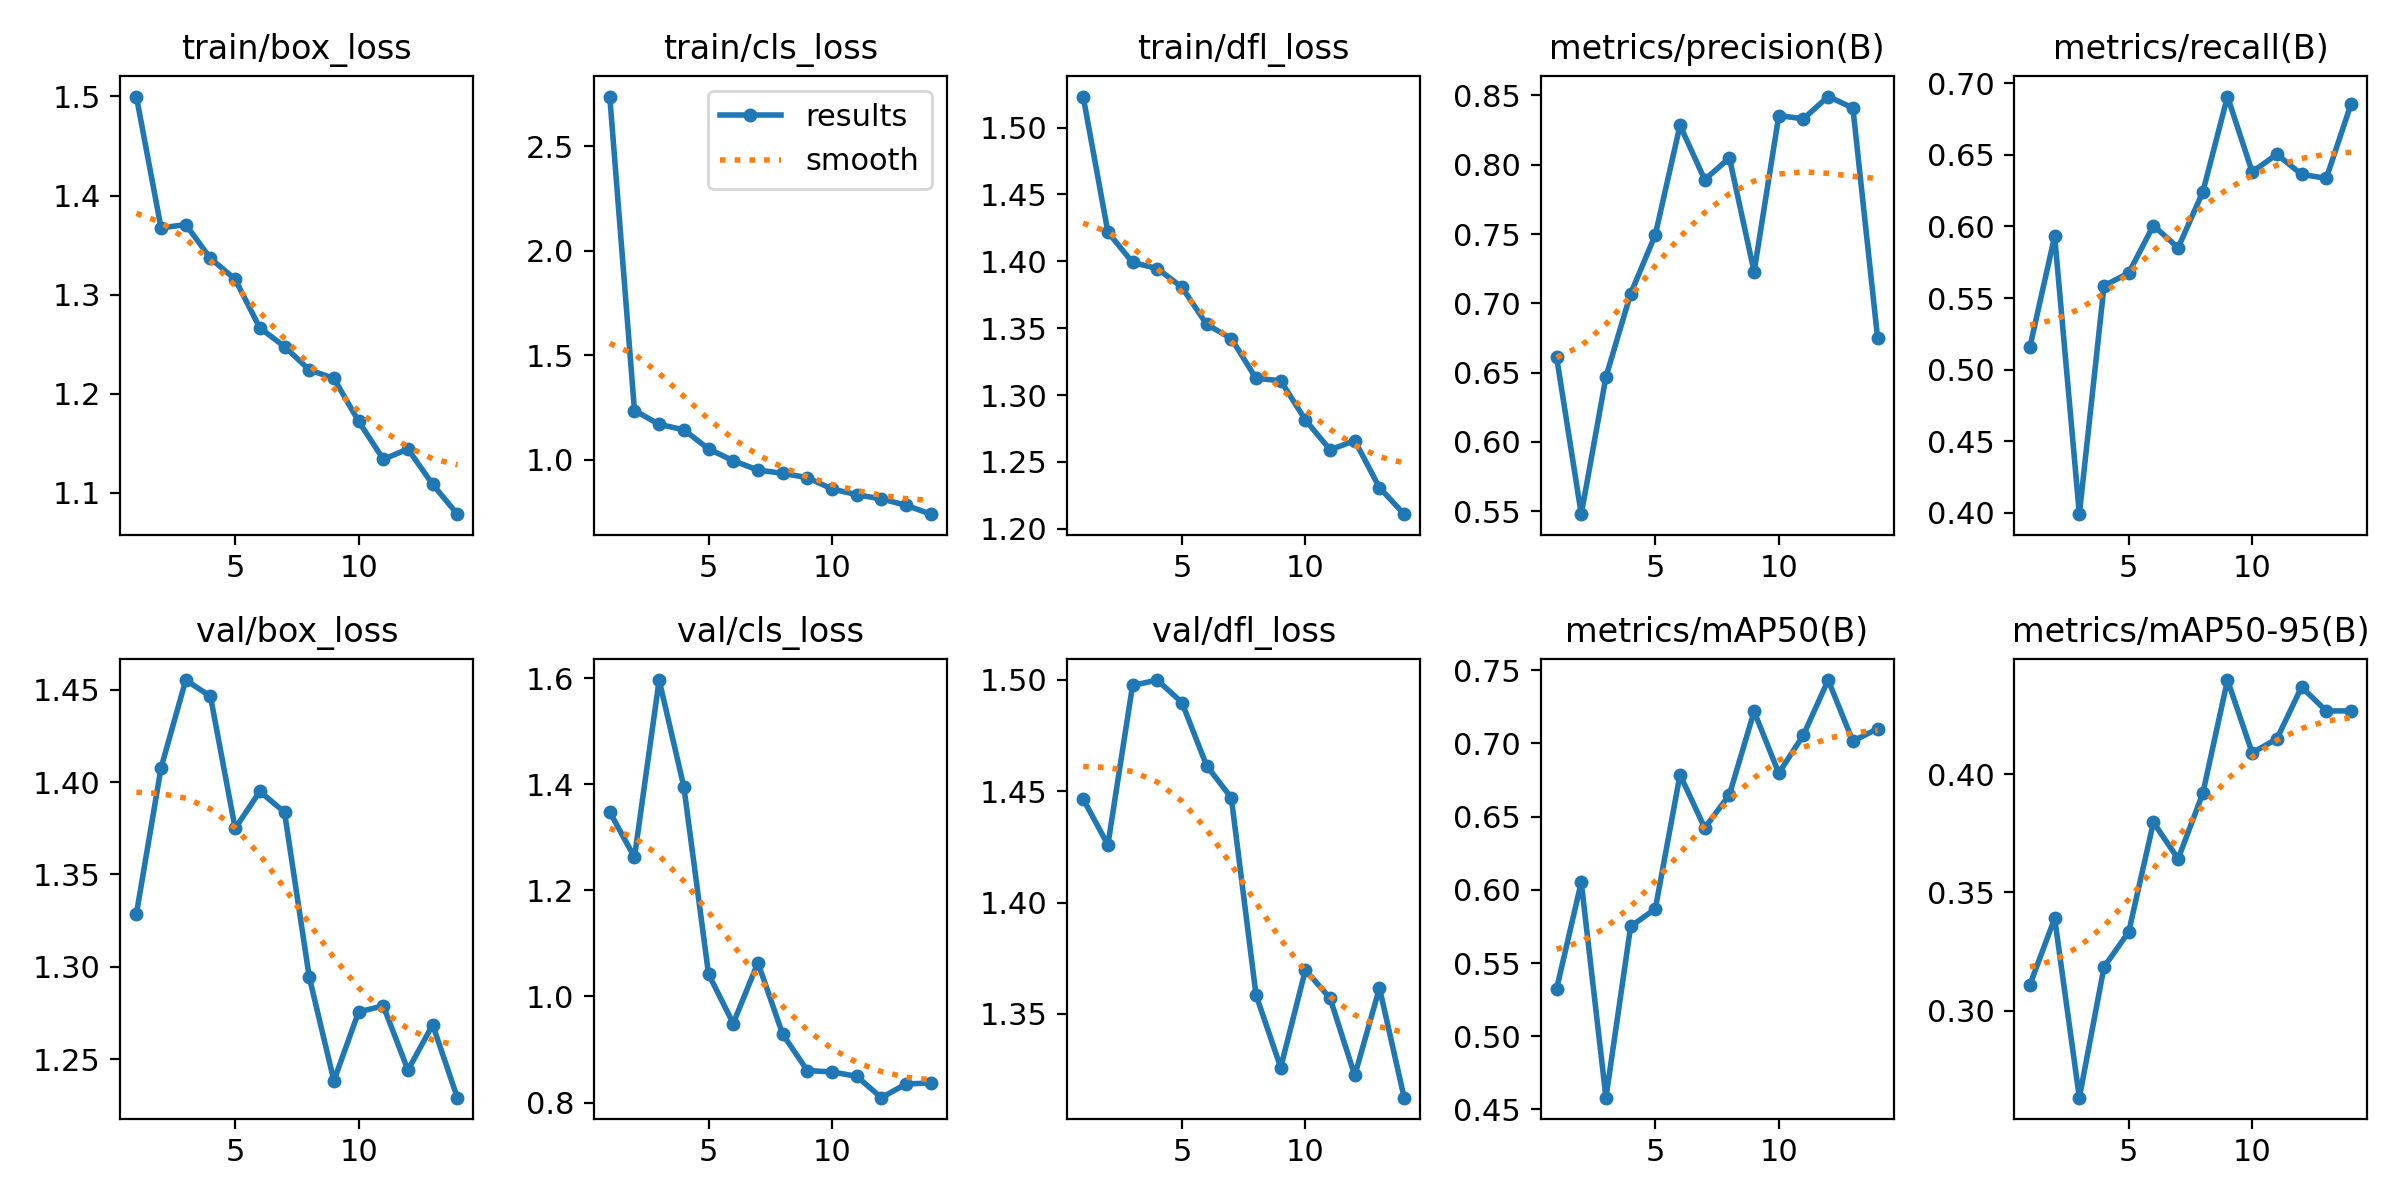

In [ ]:


# Display training metrics (loss curves, precision, recall, mAP)
display(Image(filename="/content/boda_boda_yolov8/yolov8_v1_1_model/results.png"))

###Training discussion
This visualization summarizes the training and validation performance of the YOLOv8 model over multiple epochs. The **training losses** (`train/box_loss`, `train/cls_loss`, `train/dfl_loss`) consistently decrease, indicating that the model is learning to better localize and classify objects with each epoch. Similarly, the **validation losses** also show a steady decline, suggesting that the model generalizes well without overfitting.

The **precision** and **recall** metrics both increase over time, reflecting improvements in the model’s ability to correctly detect safety attributes (helmet, reflector, load compliance) while minimizing false positives and false negatives. The **mAP@50** and **mAP@50–95** curves rise gradually, showing that detection accuracy across different IoU thresholds improves as training progresses. Overall, the curves demonstrate a healthy training pattern — decreasing loss and increasing accuracy metrics — meaning the model is converging effectively and performing reliably on the validation data.


###8.Displaying the confusion matrix
This code segment loads and displays the **normalized confusion matrix** generated by YOLOv8 after model validation. It uses `matplotlib` to visualize the matrix as an image, allowing an easy interpretation of how well the model distinguishes between classes such as *helmet*, *no helmet*, *reflector*, *no reflector*, *overload*, and *no overload*. The confusion matrix provides insight into classification accuracy — diagonal cells indicate correctly predicted classes, while off-diagonal cells show misclassifications. Displaying it helps evaluate which safety categories the model predicts most confidently and where confusion between classes still exists.


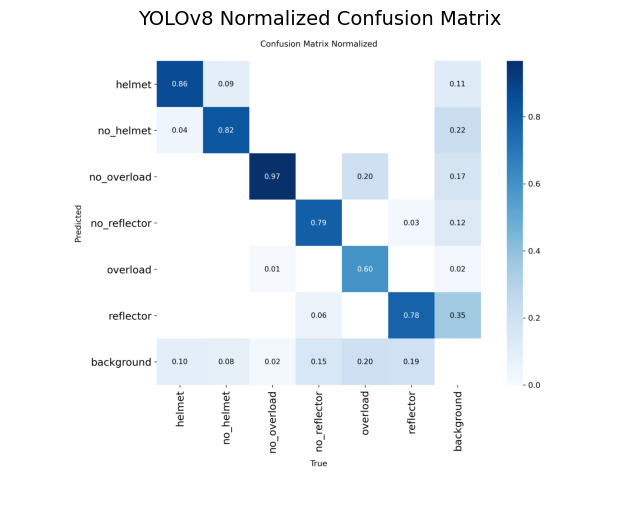

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to your preferred confusion matrix
conf_matrix_path = "/content/runs/detect/val/confusion_matrix_normalized.png"

# Load and display
img = mpimg.imread(conf_matrix_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title("YOLOv8 Normalized Confusion Matrix", fontsize=14)
plt.show()


###Confusion matrix discussion

This YOLOv8 normalized confusion matrix shows how well the model distinguishes between six classes: *helmet, no_helmet, no_overload, no_reflector, overload,* and *reflector,* with *background* included as well. The diagonal values represent correct predictions, where higher numbers indicate better performance. For example, *no_overload* (0.97) and *helmet* (0.86) are detected very accurately, while *overload* (0.60) and *no_reflector* (0.79) show more confusion with similar classes. Misclassifications, such as *reflector* sometimes being mistaken for *background* (0.35), indicate where the model struggles. Overall, the model performs well but could improve in distinguishing reflective items and overload conditions.
